# 04 - Model 2: multi-task residual CNN

A deeper CNN trained from scratch, built with the Functional API. Instead of one 16-way softmax it has two outputs that share the same convolutional trunk:

- **fruit**: softmax over the 8 fruits,
- **freshness**: one sigmoid unit, the probability that the fruit is spoiled.

The trunk is a small ResNet: a stem (Conv 3x3 with stride 2, batch norm, ReLU, MaxPool) and four residual blocks with 64, 128, 256 and 512 filters. Global average pooling replaces Flatten, so there is no huge dense layer as in Model 1.

In [1]:
import os, sys
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
sys.path.insert(0, os.path.abspath(".."))
import tensorflow as tf
tf.get_logger().setLevel("ERROR")

import time
import keras
from keras import layers
import pandas as pd
import matplotlib.pyplot as plt

from src.config import FIGURES_DIR, IMG_SIZE, LOGS_DIR, MODELS_DIR, NUM_FRUITS, REPORTS_DIR, SEED
from src.data_pipeline import load_split, make_dataset
from src.evaluation import compute_metrics, predict
%matplotlib inline

In [2]:
RUN = "model2_multitask_cnn"
BATCH_SIZE = 32
EPOCHS = 40
LEARNING_RATE = 1e-3
DROPOUT = 0.3
LOSS_WEIGHTS = {"fruit": 1.0, "freshness": 1.0}

# True: train lại từ đầu (khoảng 2 giờ trên CPU); False: load model và lịch sử train đã lưu
TRAIN = False

## 1. Data

Two labels per image: `fruit` (0-7) and `freshness` (0 = fresh, 1 = spoiled). Same augmentation as Model 1.

In [3]:
keras.utils.set_random_seed(SEED)
train_ds = make_dataset("train", label_mode="multitask", batch_size=BATCH_SIZE, augment=True)
val_ds = make_dataset("val", label_mode="multitask", batch_size=BATCH_SIZE)
val_df = load_split("val")
x, y = next(iter(val_ds))
print("images", x.shape, "| labels", {k: v.shape for k, v in y.items()})

images (32, 224, 224, 3) | labels {'fruit': TensorShape([32]), 'freshness': TensorShape([32])}


## 2. Model

A residual block computes `ReLU(F(x) + shortcut(x))`, where `F` is Conv - BN - ReLU - Conv - BN. When the block halves the resolution (stride 2) or changes the number of filters, the shortcut is a 1x1 convolution with the same stride (plus batch norm), so both terms have the same shape; otherwise it is the input itself. The shortcut lets the gradient flow directly to the earlier layers, which makes deeper networks easier to train. Batch normalisation normalises the activations over each mini-batch, which speeds up training and also regularises a little.

In [4]:
def residual_block(x, filters, strides, name):
    shortcut = x
    y = layers.Conv2D(filters, 3, strides=strides, padding="same", use_bias=False, name=f"{name}_conv1")(x)
    y = layers.BatchNormalization(name=f"{name}_bn1")(y)  # chuẩn hoá theo mini-batch: train nhanh và ổn định hơn
    y = layers.Activation("relu", name=f"{name}_relu1")(y)
    y = layers.Conv2D(filters, 3, padding="same", use_bias=False, name=f"{name}_conv2")(y)
    y = layers.BatchNormalization(name=f"{name}_bn2")(y)
    if strides != 1 or x.shape[-1] != filters:  # khác kích thước thì dùng Conv 1x1 để shortcut cùng shape với y
        shortcut = layers.Conv2D(filters, 1, strides=strides, use_bias=False, name=f"{name}_proj")(x)
        shortcut = layers.BatchNormalization(name=f"{name}_proj_bn")(shortcut)
    y = layers.Add(name=f"{name}_add")([y, shortcut])  # residual: F(x) + x, gradient truyền ngược dễ hơn khi mạng sâu
    return layers.Activation("relu", name=f"{name}_out")(y)


def build_heads(features, dropout):
    # GlobalAveragePooling: lấy trung bình mỗi feature map, ít tham số hơn nhiều so với Flatten
    pooled = layers.GlobalAveragePooling2D(name="gap")(features)
    fruit = layers.Dense(128, activation="relu", name="fruit_fc")(pooled)
    fruit = layers.Dropout(dropout, name="fruit_dropout")(fruit)
    fruit = layers.Dense(NUM_FRUITS, activation="softmax", name="fruit")(fruit)  # 8 loại quả
    fresh = layers.Dense(64, activation="relu", name="freshness_fc")(pooled)
    fresh = layers.Dropout(dropout, name="freshness_dropout")(fresh)
    fresh = layers.Dense(1, activation="sigmoid", name="freshness")(fresh)  # sigmoid: xác suất quả bị hỏng
    return fruit, fresh


def build_multitask_cnn(dropout=0.3):
    inputs = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3), name="image")
    x = layers.Rescaling(1.0 / 255, name="rescale")(inputs)
    x = layers.Conv2D(32, 3, strides=2, padding="same", use_bias=False, name="stem_conv")(x)
    x = layers.BatchNormalization(name="stem_bn")(x)
    x = layers.Activation("relu", name="stem_relu")(x)
    x = layers.MaxPooling2D(2, name="stem_pool")(x)
    for stage, filters in enumerate([64, 128, 256, 512], start=1):
        x = residual_block(x, filters, strides=1 if stage == 1 else 2, name=f"stage{stage}_block1")
    fruit, freshness = build_heads(x, dropout)
    model = keras.Model(inputs, {"fruit": fruit, "freshness": freshness}, name="model2_multitask_cnn")
    model.compile(
        optimizer=keras.optimizers.Adam(LEARNING_RATE),
        # loss tổng = loss loại quả + loss tươi/hỏng (trọng số 1 : 1); sigmoid đi với binary cross-entropy
        loss={"fruit": "sparse_categorical_crossentropy", "freshness": "binary_crossentropy"},
        loss_weights=LOSS_WEIGHTS,
        metrics={"fruit": ["accuracy"], "freshness": ["accuracy", keras.metrics.AUC(name="auc")]},
    )
    return model


model = build_multitask_cnn(DROPOUT)
model.summary()

Model: "model2_multitask_cnn"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image (InputLayer)  │ (None, 224, 224,  │          0 │ -                 │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescale (Rescaling) │ (None, 224, 224,  │          0 │ image[0][0]       │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        864 │ rescale[0][0]     │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_relu           │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_pool           │ (None, 56, 56,    │          0 │ stem_relu[0][0]   │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage1_block1_conv1 │ (None, 56, 56,    │     18,432 │ stem_pool[0][0]   │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage1_block1_bn1   │ (None, 56, 56,    │        256 │ stage1_block1_co… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage1_block1_relu1 │ (None, 56, 56,    │          0 │ stage1_block1_bn… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage1_block1_conv2 │ (None, 56, 56,    │     36,864 │ stage1_block1_re… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage1_block1_proj  │ (None, 56, 56,    │      2,048 │ stem_pool[0][0]   │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage1_block1_bn2   │ (None, 56, 56,    │        256 │ stage1_block1_co… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage1_block1_proj… │ (None, 56, 56,    │        256 │ stage1_block1_pr… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage1_block1_add   │ (None, 56, 56,    │          0 │ stage1_block1_bn… │
│ (Add)               │ 64)               │            │ stage1_block1_pr… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage1_block1_out   │ (None, 56, 56,    │          0 │ stage1_block1_ad… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage2_block1_conv1 │ (None, 28, 28,    │     73,728 │ stage1_block1_ou… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage2_block1_bn1   │ (None, 28, 28,    │        512 │ stage2_block1_co

 Total params: 4,986,345 (19.02 MB)

 Trainable params: 4,980,521 (19.00 MB)

 Non-trainable params: 5,824 (22.75 KB)

The loss is the sum of the two task losses: sparse categorical cross-entropy for the fruit and binary cross-entropy for the freshness (weights 1 : 1).

## 3. Training

Same optimizer and callbacks as Model 1. This run was interrupted once (the computer was shut down). It was continued from the checkpoint of the best epoch so far (epoch 17), including the optimizer state, and early stopping ended it at epoch 25. The history below contains the epochs of the final run.

In [5]:
def make_callbacks(run):
    (LOGS_DIR / run).mkdir(parents=True, exist_ok=True)
    MODELS_DIR.mkdir(exist_ok=True)
    return [
        # lưu lại epoch có val_loss thấp nhất
        keras.callbacks.ModelCheckpoint(str(MODELS_DIR / f"{run}.keras"), monitor="val_loss", save_best_only=True),
        # dừng khi val_loss không giảm sau 8 epoch, lấy lại trọng số tốt nhất
        keras.callbacks.EarlyStopping(monitor="val_loss", patience=8, restore_best_weights=True, verbose=1),
        # giảm learning rate còn 0.3 lần khi val_loss không giảm sau 3 epoch
        keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.3, patience=3, min_lr=1e-6, verbose=1),
        keras.callbacks.CSVLogger(str(LOGS_DIR / run / "history.csv")),
    ]


def save_to_log(row):
    path = REPORTS_DIR / "experiment_log.csv"
    log = pd.read_csv(path)
    log = pd.concat([log[log["run"] != row["run"]], pd.DataFrame([row])], ignore_index=True)
    log.to_csv(path, index=False)


if TRAIN:
    t0 = time.time()
    model.fit(train_ds, validation_data=val_ds, epochs=EPOCHS, callbacks=make_callbacks(RUN), verbose=2)
    minutes = (time.time() - t0) / 60

model = keras.models.load_model(MODELS_DIR / f"{RUN}.keras")
history = pd.read_csv(LOGS_DIR / RUN / "history.csv")
best = history["val_loss"].idxmin()
print(f"{len(history)} epochs, best epoch {best + 1}: val_loss {history.val_loss[best]:.4f}")
show = history[["loss", "fruit_accuracy", "freshness_accuracy", "val_loss", "val_fruit_accuracy",
                "val_freshness_accuracy", "learning_rate"]]
show.index = show.index + 1
show.tail(10)

25 epochs, best epoch 17: val_loss 0.1076


,loss,fruit_accuracy,freshness_accuracy,val_loss,val_fruit_accuracy,val_freshness_accuracy,learning_rate
16,0.090453,0.982461,0.987209,0.130880,0.979573,0.987744,0.000027
17,0.086546,0.985271,0.987791,0.107566,0.982751,0.989106,0.000027
18,0.077265,0.987791,0.987209,0.140068,0.979573,0.984113,0.000027
19,0.085383,0.983236,0.988178,0.134633,0.974580,0.989560,0.000027
20,0.076409,0.985853,0.988372,0.113006,0.982751,0.989106,0.000027
21,0.073286,0.987791,0.988469,0.124849,0.981389,0.985474,0.000008
22,0.066865,0.988857,0.989922,0.119087,0.982751,0.989560,0.000008
23,0.067936,0.989341,0.989050,0.132211,0.980481,0.983659,0.000008
24,0.070093,0.988372,0.989632,0.125006,0.982297,0.985474,0.000002
25,0.070319,0.987500,0.989922,0.114288,0.983205,0.990468,0.000002


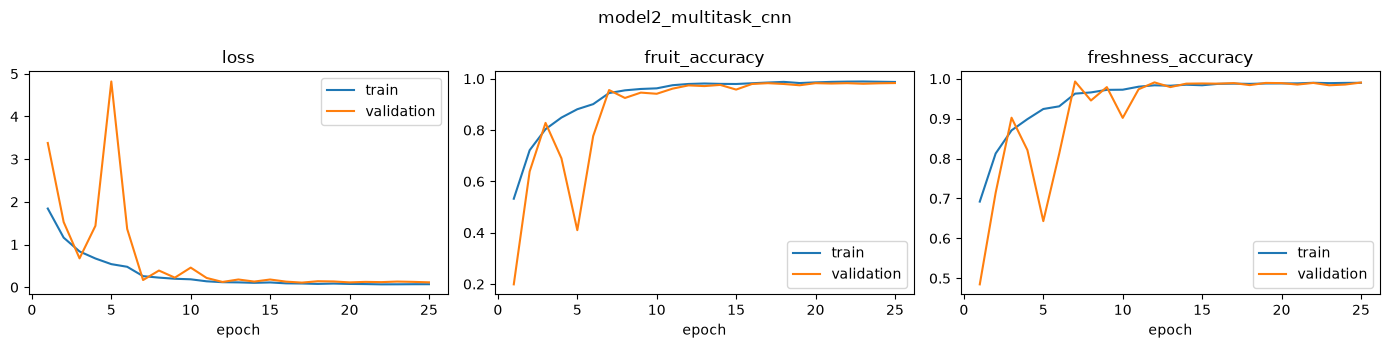

In [6]:
def plot_history(history, title):
    epochs = range(1, len(history) + 1)
    fig, axes = plt.subplots(1, 3, figsize=(14, 3.5))
    for ax, key in zip(axes, ["loss", "fruit_accuracy", "freshness_accuracy"]):
        ax.plot(epochs, history[key], label="train")
        ax.plot(epochs, history["val_" + key], label="validation")
        ax.set_title(key)
        ax.set_xlabel("epoch")
        ax.legend()
    fig.suptitle(title)
    plt.tight_layout()
    return fig


fig = plot_history(history, RUN)
fig.savefig(FIGURES_DIR / "learning_curves" / f"{RUN}.png", dpi=150, bbox_inches="tight")

The validation accuracies follow the training accuracies closely. The training accuracy is measured with augmentation and dropout switched on, so it can even be a little lower than the validation accuracy.

## 4. Validation results

In [7]:
metrics = compute_metrics(val_df, predict(model, val_ds))
if TRAIN:
    save_to_log({"run": RUN, "model": "multitask_cnn", "augmentation": True, "learning_rate": LEARNING_RATE,
                 "max_epochs": EPOCHS, "epochs_trained": len(history), "best_epoch": best + 1,
                 "train_minutes": round(minutes, 1), **{f"val_{k}": round(v, 4) for k, v in metrics.items()},
                 "params": model.count_params()})
pd.Series(metrics).round(4).to_frame("validation")

,validation
fruit_accuracy,0.9828
fruit_precision,0.9830
fruit_recall,0.9826
fruit_f1,0.9826
freshness_accuracy,0.9891
freshness_precision,0.9810
freshness_recall,0.9992
freshness_f1,0.9900
freshness_macro_f1,0.9890
freshness_auc,0.9996


## 5. Ablation: no data augmentation

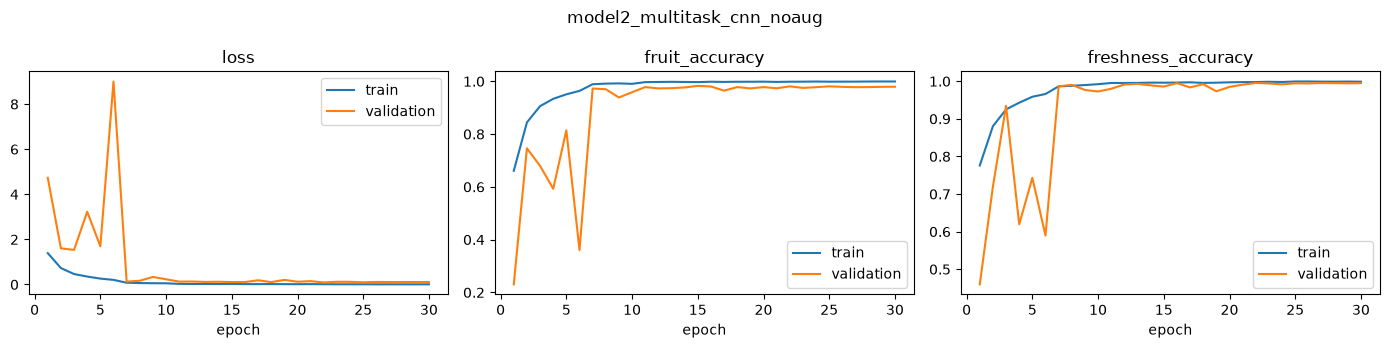

In [8]:
RUN_NOAUG = RUN + "_noaug"
if TRAIN:
    keras.utils.set_random_seed(SEED)
    train_plain = make_dataset("train", label_mode="multitask", batch_size=BATCH_SIZE, augment=False)
    model_noaug = build_multitask_cnn(DROPOUT)
    t0 = time.time()
    model_noaug.fit(train_plain, validation_data=val_ds, epochs=EPOCHS, callbacks=make_callbacks(RUN_NOAUG), verbose=2)
    minutes = (time.time() - t0) / 60

model_noaug = keras.models.load_model(MODELS_DIR / f"{RUN_NOAUG}.keras")
history_noaug = pd.read_csv(LOGS_DIR / RUN_NOAUG / "history.csv")
metrics_noaug = compute_metrics(val_df, predict(model_noaug, val_ds))
if TRAIN:
    save_to_log({"run": RUN_NOAUG, "model": "multitask_cnn", "augmentation": False, "learning_rate": LEARNING_RATE,
                 "max_epochs": EPOCHS, "epochs_trained": len(history_noaug),
                 "best_epoch": int(history_noaug["val_loss"].idxmin()) + 1, "train_minutes": round(minutes, 1),
                 **{f"val_{k}": round(v, 4) for k, v in metrics_noaug.items()}, "params": model_noaug.count_params()})
fig = plot_history(history_noaug, RUN_NOAUG)
fig.savefig(FIGURES_DIR / "learning_curves" / f"{RUN_NOAUG}.png", dpi=150, bbox_inches="tight")

In [9]:
def summary(history, metrics):
    best = history.loc[history["val_loss"].idxmin()]
    return {"epochs trained": len(history), "best epoch": int(history["val_loss"].idxmin()) + 1,
            "train fruit accuracy (last epoch)": history["fruit_accuracy"].iloc[-1],
            "train freshness accuracy (last epoch)": history["freshness_accuracy"].iloc[-1],
            "train loss (best epoch)": best["loss"], "val loss (best epoch)": best["val_loss"],
            "val joint accuracy": metrics["joint_accuracy"], "val freshness F1": metrics["freshness_f1"]}


pd.DataFrame({"with augmentation": summary(history, metrics),
              "without augmentation": summary(history_noaug, metrics_noaug)}).round(4)

,with augmentation,without augmentation
epochs trained,25.0000,30.0000
best epoch,17.0000,22.0000
train fruit accuracy (last epoch),0.9875,0.9994
train freshness accuracy (last epoch),0.9899,0.9988
train loss (best epoch),0.0865,0.0120
val loss (best epoch),0.1076,0.0905
val joint accuracy,0.9755,0.9764
val freshness F1,0.9900,0.9958


Without augmentation the training accuracy gets closer to 100 % and the gap between training and validation loss grows, but the validation results stay about the same. Unlike Model 1, this model has no large dense layer and uses batch normalisation, so on this dataset it does not depend on augmentation. Test results: notebook 06.